![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/notebooks_banner_withframe.png)

# **Single-Species Single-Season Occupancy Model - Conceptual**

Author details: Xiang Zhao, Dr Zachary Amir

Editor details: Dr Zachary Amir

Contact details: support\@ecocommons.org.au

Copyright statement: This script is the product of the EcoCommons and WildObs team. Please refer to the EcoCommons website for more details: https://www.ecocommons.org.au/

For more information about WildObs, please visit https://wildobs.org.au and https://github.com/WildObs



Date: October 2025

# **Script information**

There are two notebooks about Single-Species Single-Season Occupancy Model, one is conceptual, and another is pratical. This one is the **conceptual** one which gives a brief introduction to the concepts of Single-Species Single-Season Occupancy Model with some simulated data.

This notebook, developed by the EcoCommons and WildObs team, showcases how to build Single-Species Single-Season Occupancy Model with camera trapping data with 'unmarked" R package.

## Other file formats of this notebook

| Notebook | Files | Open in Colab / ARDC Jupyter | DOI |
|:---:|:---:|:---:|:---:|
| Single-Species Single-Season Occupancy Model - Conceptual | <a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/EC_Occupancy_conceptual.ipynb"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/jupyter_notebook.png" width="40%"></a>&nbsp;&nbsp;<a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/EC_Occupancy_conceptual.qmd"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/quartomd.png" width="40%"></a> | [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecocommonsaustralia/notebooks/blob/main/notebooks/EC_Occupancy_conceptual.ipynb) | [![DOI](https://img.shields.io/badge/DOI-10.5281%2Fzenodo.19552238-blue)](https://doi.org/10.5281/zenodo.19552238) |

# **Introduction**

It explains the fundamental theory behind occupancy modelling — estimating the probability that a species occupies a site while accounting for imperfect detection. Through clear explanations and simulated examples, it demonstrates how occupancy and detection processes are modelled using R and the unmarked package.

# **Wildlife Observatory of Australia**

<img src="https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/WildObs%20Logo%28cropped%2Btransparent%29.png" alt="WildObs logo" width="400">

Wildlife Observatory of Australia - Australia’s national platform for processing and sharing wildlife camera data. WildObs will transform how Australia handles wildlife camera data by creating a national platform powered by AI. It will streamline biodiversity monitoring, break down data silos, and support effective conservation strategies by providing researchers and policymakers with easy access to consistent, high-quality data for informed decision-making. The WildObs researcher network is supported by Australia's National Research Infrastructure. TERN supports the field observatory and standard protocols, ALA hosts the tagged image repository and ARDC Planet Research Data Commons, through QCIF, is building a user-friendly data management and access platform.

For more information about WildObs, please visit https://wildobs.org.au and https://github.com/WildObs

# **Objectives**

-   To explain the core principles and assumptions of occupancy modelling.

-   To illustrate the distinction between occupancy (ψ) and detection (p) probabilities.

-   To demonstrate hand and R-based (likelihood) calculations of a simple detection-only occupancy model.

-   To introduce the use of site and survey covariates in modelling occupancy and detection probabilities.

-   To prepare readers for the accompanying *Practical Notebook*, which applies these concepts to real camera trap data.

# **Workflow Overview**

| **Notebook** | **Main Content** | **Sub-content** |
|---------------|------------------|-----------------|
| **Single-Species Single-Season Occupancy Model – Conceptual** | Overview and Conceptualisation | 1.1 What is Occupancy Modelling?  <br> <br> 1.2 Single-species, single-season occupancy model and assumptions  <br> <br> 1.3 Single-species, single-season occupancy model with covariates |
| **Single-Species Single-Season Occupancy Model – Practical** | Occupancy Model with Camera Traps | 1.1 Camera Trap  <br> <br> 1.2 Camera trap surveys in Queensland’s Wet Tropics 2022–2023  <br> <br> 1.3 How to prepare camera trap data for occupancy model  <br> <br> 1.4 Occupancy model with WildObs data |

In the near future, this material may form part of comprehensive support materials available to EcoCommons users. If you have any corrections or suggestions to improve the efficiency, please [contact the EcoCommons](mailto:support@ecocommons.org.au) team.




![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)


# **Set-up: R Environment and Packages**

Some housekeeping before we start. This process might take some time as many packages needed to be installed.

## **S.1 Set the working directory and create a folder for data.**

Save the Quarto Markdown file (.QMD) to a folder of your choice, and then set the path to your folder as your working directory.


In [ ]:

# Set the workspace to the current working directory
# Uncomment and replace the path below with your own working directory if needed:
# setwd("/Users/zhaoxiang/Documents/tmp/EC_GLM_notebook")

workspace <- getwd()  # Get the current working directory and store it in 'workspace'

# Increase the plot size by adjusting the options for plot dimensions in the notebook output
options(repr.plot.width = 16, repr.plot.height = 8)  # Sets width to 16 and height to 8 for larger plots



Ideally, you would use the **`renv`** package to create an isolated environment for installing all the required R packages used in this notebook. However, since installing **`renv`** and its dependencies can be time-consuming, we recommend trying this after the workshop.


In [ ]:

# # Ensure "renv" package is installed
# if (!requireNamespace("renv", quietly = TRUE)) {
#   install.packages("renv")
# }
#
# # Check if renv has been initialized in the project
# if (!file.exists("renv/activate.R")) {
#   message("renv has not been initiated in this project. Initializing now...")
#   renv::init()  # Initialize renv if not already set up
# } else {
#   source("renv/activate.R")  # Activate the renv environment
#   message("renv is activated.")
# }
#
# # Check for the existence of renv.lock and restore the environment
# if (file.exists("renv.lock")) {
#   message("Restoring renv environment from renv.lock...")
#   renv::restore()
# } else {
#   message("No renv.lock file found in the current directory. Skipping restore.")
# }



## **S.2 Install and load essential libraries.**

Install and load R packages.


In [ ]:

# Set CRAN mirror
options(repos = c(CRAN = "https://cran.rstudio.com/"))

# Required packages
packages <- c("unmarked", "ggplot2", "dplyr")

# Install any missing packages
for (pkg in packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg)
  }
  library(pkg, character.only = TRUE)
}


# If you are using renv, you can snapshot the renv after loading all the packages.

#renv::snapshot()


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘reformulas’, ‘TMB’, ‘RcppArmadillo’, ‘RcppEigen’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union





# **1 Overview and Conceptualisation**

## **1.1 What is Occupancy modelling?**

Occupancy modelling is an approach to estimating the proportion of sites occupied by a species of interest while accounting for the fact that we might fail to detect it even if it is there (possibility of non-detection) (Bailey et al., 2014; MacKenzie et al., 2002). An occupancy model separates two process:

-   **Occupancy:** the probability the species actually occurs at the site.

-   **Detection:** the probability of detecting the species given that it is present.

Not detecting a species at a site does not necessarily mean the species is absent - unless we know the probability of detection is truly zero, such as when the site is entirely unsuitable habitat or a species has gone locally extinct. For example, imagine you are trying to figure out if a shy cat lives in your neighbour's yard, just because you don't see the cat when you look doesn't mean it's not there - it might be hiding. If you check multiple times, the chances of spotting it increase. Occupancy models work the same way: they estimate both the chance the cat (species) really lives and the change you'll actually spot it (detection).

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/occupancy_illustration.png)

**Figure 1.** Illustration of Occupancy Model: Occupancy and Detection~

## **1.2 Single-species, single-season occupancy model and assumptions**

Here we use the classic sampling situation defined by MacKenzie et al. (2002): consider situations in which surveys of species at *I* specific sites are performed at *J* distinct occasion time (survey these *I* sites for *J* times). Sites are occupied by the species of interest for the duration of the survey period, with no new sites becoming occupied after surveying has begun, and no sites abandoned before the cessation of surveying (i.e., the sites are ‘‘closed’’ to changes in occupancy).

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/Closed_Occupancy%20_Survey_Design.png)

**Figure 2.**Basic sampling situation~

**Occupancy:** the probability that the study species (*A*) occupies, or uses, a study site (*i)* during a specified period of time (*t*) during which the occupancy state is assumed to be static.

-   **ψ** ~=~ the probability that a site is occupied by the target species.

**Detection:** the probability of detecting the species given that it is present.

-   ***p~=~*** the probability of detecting the species at an occupied a site during the an independent survey of the site.

**Assumptions**

-   **Closure** – The occupancy state of each site does not change during the survey period (no colonization of new sites or extinction from occupied sites).

-   **Equal occupancy probability** (**ψ**) – The probability of occupancy (**ψ**) is assumed to be the same across all sites.

-   **Equal detection probability** (***p***) – The probability of detecting the species in a survey, given it is present (***p***), is the same across all sites and surveys.

-   **Independence of detections** – Detection events at a site are independent across visits, conditional on occupancy.

-   **Independence across sites** – Detection histories observed at different sites are independent. This means we assume we are not detecting the same individual across multiple sites.

-   **No false positives** – A recorded detection (“1”) means the species was truly present.

For example, the likelihood for Site 1 with detection history (***h~1~***) 1010 would be


$$
\Pr(h_1 = 1010) \;=\; \psi \; p_1 \; (1 - p_2) \; p_3 \; (1 - p_4)
$$

For sites at which the species was never detected, there are two situations:

1.  the site was occupied by the species and the species was not detected in any surveys, like site 4.


$$
\Pr(h_4 = 1010) \;=\; \psi \prod_{j=1}^{4} (1 - p_j)
$$


2.  the site was not occupied by the species at all (site 2).


$$
\Pr(h_2 = 0000) \;=\; \psi \prod_{j=1}^{4} (1 - p_{j}) \;+\; (1 - \psi)
$$

Under the six assumptions mentioned above, a **single-species, single-season occupancy model** can be modelled as:

$$
\Pr(Y = y_i) =
\begin{cases}
  \psi \binom{K}{y_i} p^{y_i} (1-p)^{K-y_i}, & y_i > 0 \\\\[1em]
  \psi (1-p)^K + (1-\psi), & y_i = 0
\end{cases}
$$

for more detailed explanation of the statistics, please refer to Bailey et al. (2014), MacKenzie et al. (2002), and MacKenzie et al. (2017).

### 1.2.1 Hand Calculation

For example, if we have the data for one species in three sites (1, 2, 3) and over four independent surveys (1, 2, 3, 4).

| Site   | Survey 1 | Survey 2 | Survey 3 | Survey 4 |
|--------|----------|----------|----------|----------|
| site1  | 0        | 1        | 1        | 1        |
| site 2 | 1        | 0        | 1        | 0        |
| site 3 | 0        | 0        | 0        | 0        |

we can calculate by hand with :

**Step 1: Naïve occupancy** (the simplest way to estimate occupancy from detection–nondetection data.）

only 2 out of 3 sites had detections

$$
\psi_{\text{naïve}} = \frac{2}{3} = 0.67
$$

This is usually an **underestimate of true occupancy**, because sometimes a species may be present but go undetected at a site.

**Step 2. Detection probability estimate (*p*)**

We only estimate p from **sites where there was at least one detection** (sites 1 and 2).

-   Site 1: 3 detections / 4 surveys

-   Site 2: 2 detections / 4 surveys

Total detections = 5 of 8 surveys

$$
\hat{p} = \frac{5}{8} = 0.625
$$

**Step 3. Refined occupancy estimate**

For an occupied site, the probability of **never detecting** across 4 surveys is:

$$
\Pr(\text{no detections} \mid \text{occupied}) = (1 - \hat{p})^K
= (1 - 0.625)^4
= 0.375^4
\approx 0.0198
$$

So the probability of **≥1 detection** at an occupied site is:

$$
\Pr(\text{≥1 detection} \mid \text{occupied})
= 1 - (1 - \hat{p})^4
= 1 - 0.0198
\approx 0.9802
$$

Observed proportion of sites with ≥1 detection = 2/3 = 0.667.

Estimated true occupancy:

$$
\hat{\psi} = \frac{0.667}{0.9802} \approx 0.68
$$

### **1.2.2 Calculating with 'unmarked' R package**

A better way of calculating using the **likelihood-based estimation** with **'unmarked'** R package.


In [ ]:

## 1) Detection histories (rows = sites, cols = surveys)
y <- matrix(c(
  0, 1, 1, 1,   # site 1
  1, 0, 1, 0,   # site 2
  0, 0, 0, 0    # site 3
), nrow = 3, byrow = TRUE)

rownames(y) <- c("site1", "site2", "site3")
colnames(y) <- paste0("survey", 1:4)

## 2) Unmarked frame
umf <- unmarkedFrameOccu(y = y)

## 3) Detection-only occupancy model (no covariates)
fm <- occu(~ 1 ~ 1, data = umf)

## 4) Extract estimates and confidence intervals
psi_hat <- backTransform(fm, type = "state")  # occupancy ψ
p_hat   <- backTransform(fm, type = "det")    # detection p

K <- ncol(y)
p  <- p_hat@estimate
p_atleast1 <- 1 - (1 - p)^K

## 5) Print tidy one-page summary
cat("Detection-only Occupancy Model Results\n")
cat("--------------------------------------\n")
cat("Naïve occupancy (>=1 detection per site): ",
    round(mean(rowSums(y) > 0), 3), "\n", sep = "")
cat("Model-based ψ (estimate [LCI, UCI]): ",
    round(psi_hat@estimate, 3), " [",
    paste(round(confint(psi_hat), 3), collapse = ", "), "]\n", sep = "")
cat("Detection p (estimate [LCI, UCI]): ",
    round(p_hat@estimate, 3), " [",
    paste(round(confint(p_hat), 3), collapse = ", "), "]\n", sep = "")
cat("P(>=1 detection | occupied): ",
    round(p_atleast1, 3), "\n", sep = "")

Detection-only Occupancy Model Results
--------------------------------------
Naïve occupancy (>=1 detection per site): 0.667
Model-based ψ (estimate [LCI, UCI]): 0.682 [0.146, 0.964]
Detection p (estimate [LCI, UCI]): 0.611 [0.255, 0.878]
P(>=1 detection | occupied): 0.977



We can compare the results from two methods:

| **Metric** | **Hand** | **unmarked** | **Difference** | **Interpretation** |
|-------------|-----------|---------------|----------------|--------------------|
| **Naïve occupancy** | 0.667 | 0.667 | – | Two of the three sites had at least one detection, so the raw proportion of occupied sites is 66.7%. Both methods agree exactly because this is a simple count. |
| **Detection probability (p)** | 0.625 | 0.611 | +0.014 | If a site is truly occupied, the chance of detecting the species on a single survey is about 61–63%. The hand calculation pooled detections, while *unmarked* used the full likelihood of the detection histories. Both are very close. |
| **P(≥1 detection | occupied)** | 0.980 | 0.977 | +0.003 | With four surveys per site, an occupied site has about a 98% chance of being detected at least once. This shows repeated surveys almost guarantee detection when the species is present. |
| **Model-based occupancy (ψ)** | 0.680 | 0.682 | –0.002 | After adjusting for imperfect detection, the estimated true occupancy probability is ~68%. This is slightly higher than the naïve 67%, because the model accounts for the possibility that Site 3 might actually be occupied but undetected. |

## **1.3 Single-species, single-season occupancy model with covariates**

Very often, we not only want to know the probability of a species using a site, but we also want to know what conditions contribute to the occupancy or absence of a species on a site. There could be many reasons that a species be present or be absent on a site, for example, whether the site is the suitable habitat type for them. Similarly, elevation, temperature, humidity and the distance to water of a site can result in presence or absence of a species.

Besides the occupancy, there are many things can have impact on the detection. For example, using bait can increase the probability of detection of a species. Of course, higher frequency of visiting means higher probability to see the species on a site if they are there.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/occupancy_cova.png)

Occupancy model allows us to take the site covariates and survey covariates into consideration. Using the logit link, we can express the probability of site *i* being occupied, and the true occupancy state process (*z*) as:

$$
\text{logit}(\psi_i) = \beta_0 + \beta_1 \cdot elev_{i1} + \beta_2  \cdot forest_{i2} + \cdots + \beta_U x_{iU}
$$

$$
z_i \sim Bernoulli(\psi_i)
$$ which is a function of *U* covariates associated with site *i* and their coefficients.

Similarly, we can use the logistic equation to express the probability of detecting the species at site *i* during survey *j*, as:

$$
\text{logit}(p_{ij}) = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_U x_{iU} + \beta_{U+1} y_{ij1} + \cdots + \beta_{U+V} y_{ijV}
$$ $$
y_{ij} \mid z_i \sim Bernoulli(z_i p_{ij})
$$

where *x* denote the *U* covariates associated with the site site *i* and *y* are the survey-specific covariates.

For more details, please refer to the Section 4.4 Model-based Approach in MacKenzie et al. (2017).

### **1.3.1 Occupancy model with Site and Observation covariates**

To illustrate the modelling process of an occupancy model with site- and observation-level covariates, basically, we need three matrix: (1) detection/non-detection, (2) site-level covariates (3) observational covariates. For the sake of teaching, we are going to simulate a dataset.

The below code simulates a **single-species, single-season occupancy dataset** with both site-level and observation-level covariates. It creates 100 sites, each surveyed three times, and generates synthetic data to illustrate how occupancy (ψ) and detection (p) are influenced by environmental and survey factors.

-   **Site covariates:**

    *Elevation* (continuous variable)

    *Forest* (categorical: Forest / NoForest)

-   **Observation covariates:**

    *Effort* (survey duration)

    *Time of Day* (Morning or Afternoon)

The below code defines “true” parameter values for both occupancy and detection processes, simulates presence–absence data (y) based on those probabilities, and packages everything into an **unmarkedFrameOccu** object (umf) for analysis using the unmarked package.


In [ ]:

set.seed(123)

# ---- Design ----
M <- 100   # sites
J <- 3     # surveys per site

# ---- Site covariates ----
Elevation <- rnorm(M, mean = 200, sd = 50)        # elevation in meters
Forest    <- factor(rbinom(M, 1, 0.5), labels = c("NoForest", "Forest"))

# ---- Observation covariates ----
Effort <- matrix(runif(M * J, 0.5, 2), nrow = M, ncol = J)  # survey effort (0.5–2 hrs)
TimeOfDay <- matrix(
  sample(c("Morning", "Afternoon"), M * J, replace = TRUE),
  nrow = M, ncol = J
)
# Convert TimeOfDay to factor before building UMF
TimeOfDay <- apply(TimeOfDay, 2, as.factor)

# ---- True parameters ----
# Occupancy (ψ)
beta0 <- -0.5      # intercept
beta1 <- 0.01      # Elevation effect
beta2 <- 0.8       # Forest effect

# Detection (p)
alpha0 <- -1       # intercept
alpha1 <- 0.6      # Effort effect
alpha2 <- -0.5     # Afternoon effect (vs Morning)

# ---- Latent occupancy ----
logit_psi <- beta0 + beta1 * Elevation + beta2 * (Forest == "Forest")
psi <- plogis(logit_psi)
z <- rbinom(M, 1, psi)

# ---- Detection histories ----
logit_p <- alpha0 + alpha1 * Effort + alpha2 * (TimeOfDay == "Afternoon")
p <- plogis(logit_p)

y <- matrix(0, M, J)
for (i in 1:M) {
  for (j in 1:J) {
    y[i, j] <- rbinom(1, 1, z[i] * p[i, j])
  }
}

# ---- Build UMF ----
umf <- unmarkedFrameOccu(
  y = y,
  siteCovs = data.frame(Elevation, Forest),
  obsCovs  = list(Effort = Effort, TimeOfDay = TimeOfDay)
)

Warning message:
“obsCovs contains characters. Converting them to factors.”



Let's have a look on the simulated umf


In [ ]:

# ---- Display unmarkedFrame summary ----
summary(umf)
# This prints a compact summary including:
# - number of sites
# - number of surveys
# - tabulation of y
# - summaries of site covariates
# - summaries of observation covariates



unmarkedFrame Object

100 sites
Maximum number of observations per site: 3 
Mean number of observations per site: 3 
Sites with at least one detection: 60 

Tabulation of y observations:
  0   1 
214  86 

Site-level covariates:
   Elevation           Forest  
 Min.   : 84.54   NoForest:52  
 1st Qu.:175.31   Forest  :48  
 Median :203.09                
 Mean   :204.52                
 3rd Qu.:234.59                
 Max.   :309.37                

Observation-level covariates:
     Effort           TimeOfDay  
 Min.   :0.5007   Afternoon:146  
 1st Qu.:0.8993   Morning  :154  
 Median :1.2301                  
 Mean   :1.2483                  
 3rd Qu.:1.6408                  
 Max.   :1.9991                  



### **1.3.2 Null Model**

It is suggested to run a null model first.

-   Detection formula (\~1) means no covariates on detection probability (constant detection).

-   Occupancy formula (\~1) means no covariates on occupancy probability (constant occupancy).


In [ ]:
m0 <- occu(~1 ~1, data = umf)


This gives you an intercept-only model for ψ (occupancy) and p (detection).

### **1.3.3 Test site-level covariates on occupancy (ψ)**

We have **Elevation** (continuous) and **Forest** (categorical).

Try them individually first, then together:


In [ ]:

m1 <- occu(~1 ~ Elevation, data = umf)
m2 <- occu(~1 ~ Forest, data = umf)
m3 <- occu(~1 ~ Elevation + Forest, data = umf)



This helps us see whether occupancy is better explained by site-level habitat features.

### **1.3.4 Test observation-level covariates on detection (p)**

We have **Effort** (continuous) and **TimeOfDay** (factor).

Model detection probability using these covariates while keeping occupancy constant:


In [ ]:

m4 <- occu(~ Effort ~ 1, data = umf)
m5 <- occu(~ TimeOfDay ~ 1, data = umf)
m6 <- occu(~ Effort + TimeOfDay ~ 1, data = umf)



### **1.3.5 Combine detection and occupancy covariates**

Now combine the most promising covariates for both processes:


In [ ]:

m7 <- occu(~ Effort + TimeOfDay ~ Elevation + Forest, data = umf)


If you suspect detection covariates interact (e.g., TimeOfDay modifies the effect of Effort), you can test:


In [ ]:

m8 <- occu(~ Effort * TimeOfDay ~ Elevation + Forest, data = umf)



### **1.3.6 Compare models using AIC**

Use Akaike Information Criterion (AIC) to evaluate which model best balances fit and simplicity:


In [ ]:

fitList <- fitList(
  "m0" = m0, "m1" = m1, "m2" = m2, "m3" = m3,
  "m4" = m4, "m5" = m5, "m6" = m6, "m7" = m7, "m8" = m8
)
modSel(fitList)


   nPars    AIC delta  AICwt cumltvWt
m6     4 357.37  0.00 0.4094     0.41
m4     3 357.83  0.45 0.3262     0.74
m7     6 360.38  3.00 0.0912     0.83
m0     2 361.60  4.22 0.0495     0.88
m5     3 362.18  4.80 0.0371     0.91
m8     7 362.36  4.99 0.0338     0.95
m1     3 363.14  5.77 0.0229     0.97
m2     3 363.36  5.98 0.0206     0.99
m3     4 364.93  7.56 0.0094     1.00

| **Rank** | **Model** | **ΔAIC** | **AIC Weight** | **Key Predictors** | **Interpretation** |
|-----------|-----------|-----------|----------------|--------------------|--------------------|
| **1** | m6 | 0.00 | 0.41 | Detection: Effort + TimeOfDay<br>Occupancy: constant | **Best-supported model** — detection varies with both Effort and Time of Day; occupancy doesn’t vary across sites. |
| **2** | m4 | 0.45 | 0.33 | Detection: Effort only | **Nearly as good** — Effort alone explains detection almost as well. |
| **3** | m7 | 3.00 | 0.09 | Detection: Effort + TimeOfDay<br>Occupancy: Elevation + Forest | **Moderate support** — adding site covariates slightly worsens fit. |
| **4** | m0 | 4.22 | 0.05 | No covariates (constant ψ, p) | **Much poorer fit** — covariates clearly improve detection explanation. |
| **5–9** | m5, m8, m1, m2, m3 | >4.8 | <0.04 | Various combinations | **Little to no support.** |




### **1.3.7 Interpretation**

-   The **best models (m6, m4)** differ only in whether *TimeOfDay* adds value beyond *Effort*.

    → ΔAIC \< 2 → both are statistically competitive.

-   Occupancy covariates (*Elevation*, *Forest*) don’t improve model fit — ψ is roughly constant across sites.

-   Detection covariates matter most: species detectability increases with survey effort and may differ between morning and afternoon.

In [ ]:
summary(m6)
fm <- m6   # assign final model to fm for easy plotting


Call:
occu(formula = ~Effort + TimeOfDay ~ 1, data = umf)

Occupancy (logit-scale):
 Estimate  SE    z P(>|z|)
     1.62 0.7 2.31  0.0209

Detection (logit-scale):
                 Estimate    SE     z  P(>|z|)
(Intercept)        -1.962 0.511 -3.84 0.000123
Effort              0.851 0.333  2.56 0.010588
TimeOfDayMorning    0.446 0.289  1.55 0.122336

AIC: 357.3741 
Number of sites: 100



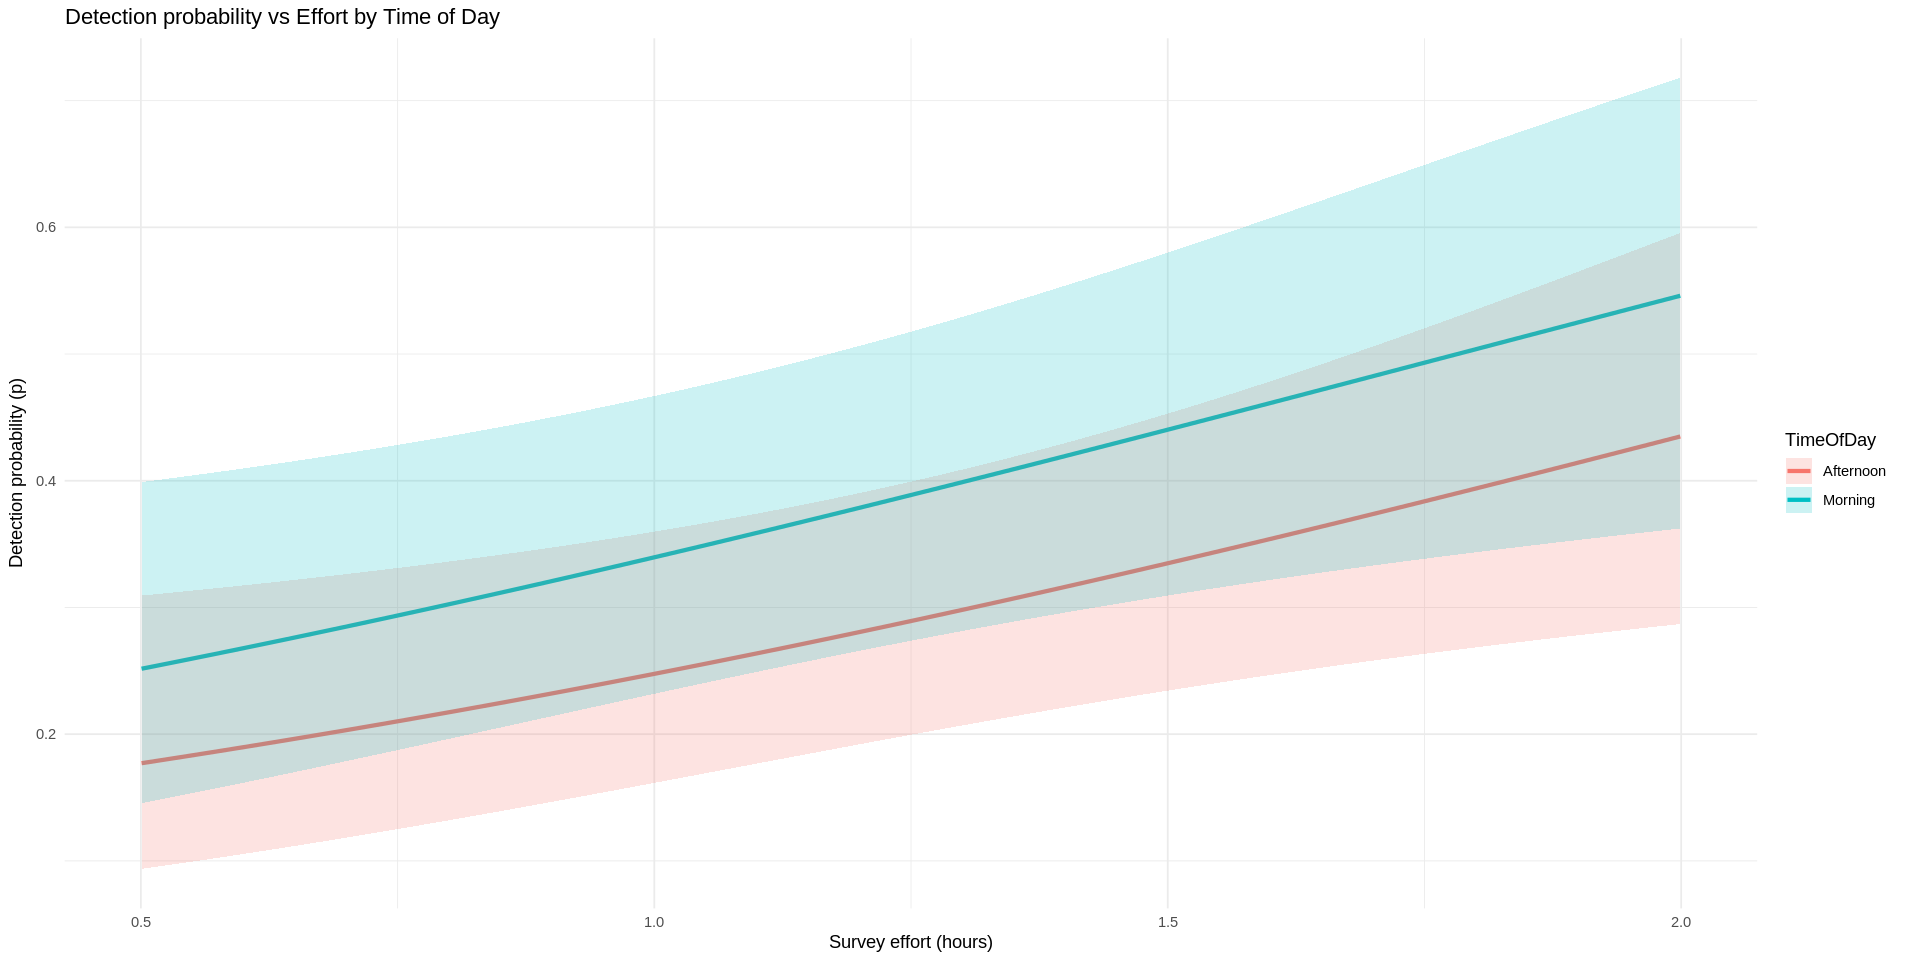

In [ ]:
newdata <- expand.grid(Effort = seq(min(obsCovs(umf)$Effort),
                                    max(obsCovs(umf)$Effort), length = 100),
                       TimeOfDay = levels(obsCovs(umf)$TimeOfDay))
preds <- predict(m6, type = "det", newdata = newdata, appendData = TRUE)

ggplot(preds, aes(x = Effort, y = Predicted, color = TimeOfDay)) +
  geom_line(linewidth = 1.2) +
  geom_ribbon(aes(ymin = lower, ymax = upper, fill = TimeOfDay),
              alpha = 0.2, color = NA) +
  labs(x = "Survey effort (hours)",
       y = "Detection probability (p)",
       title = "Detection probability vs Effort by Time of Day") +
  theme_minimal()


**What it shows**

1.  **Detection probability increases with effort** –

    Longer surveys substantially improve the likelihood of detecting the species.

    (For example, detection rises from \~0.2 to \~0.6 as effort increases from 0.5 to 2 hours.)

2.  **Morning surveys have higher detection rates** –

    The blue line is consistently above the red line, meaning species are more detectable in the morning than in the afternoon, even when effort is the same.

3.  **Confidence bands are wider at higher effort** –

    This reflects slightly greater uncertainty in predictions at the upper range of effort values, likely due to fewer observations with very long survey durations.

In this model, detectability depends on both effort and time of day: • More time spent surveying → greater chance of detecting the species if present. • Morning conditions (e.g. animal activity, lighting) make detection more likely than in the afternoon.

This confirms that accounting for observation covariates—like survey effort and time of day—is important in occupancy models to avoid underestimating true occupancy probabilities (ψ).

In the next notebook, we will use some real field collected data to give you a practical example.

# **References**

Fiske, I., & Chandler, R. (2011). Unmarked: an R package for fitting hierarchical models of wildlife occurrence and abundance. *Journal of statistical software*, *43*, 1-23.

MacKenzie, D. I., Nichols, J. D., Lachman, G. B., Droege, S., Andrew Royle, J., & Langtimm, C. A. (2002). Estimating site occupancy rates when detection probabilities are less than one. *Ecology*, *83*(8), 2248-2255.

MacKenzie, D. I., Nichols, J. D., Royle, J. A., Pollock, K. H., Bailey, L., & Hines, J. E. (2017). *Occupancy estimation and modeling: inferring patterns and dynamics of species occurrence*. Elsevier.

Bailey, L. L., MacKenzie, D. I., & Nichols, J. D. (2014). Advances and applications of occupancy models. *Methods in Ecology and Evolution*, *5*(12), 1269-1279.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_section_break.png)

EcoCommons received investment (<https://doi.org/10.3565/chbq-mr75>) from the Australian Research Data Commons (ARDC). The ARDC is enabled by the National Collaborative Research Infrastructure Strategy (NCRIS).


**Our partner**


![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/updated_ourpartner_2025.png)

## How to cite this Notebook

Zhao, X. Y., & Amir, Z. (2025). *Single-Species Single-Season Occupancy Model - Conceptual* (Version 1.0) [Computational notebook]. Zenodo. <https://doi.org/10.5281/zenodo.19552238>

# **How to Cite EcoCommons**

If you use EcoCommons in your research, please cite the platform as follows:

> EcoCommons Australia 2026. *EcoCommons Australia – a collaborative commons for ecological and environmental modelling*, Queensland Cyber Infrastructure Foundation, Brisbane, Queensland. Available at: <https://data–explorer.app.ecocommons.org.au/> (Accessed: MM DD, YYYY). <https://doi.org/10.3565/chbq-mr75>

You can download the citation file for EcoCommons Australia here: [Download the BibTeX file](reference.bib)